# HHL in Qiskit: Paper-Aligned Walkthrough

This notebook sketches the Harrow-Hassidim-Lloyd algorithm from the walkthrough paper with the paper's 4-qubit teaching layout:

- 1 system qubit for the linear-system state
- 2 clock / phase-estimation qubits
- 1 ancilla qubit for the controlled reciprocal rotation

The numerical example used throughout is the paper's Hermitian system

$$
A = \begin{bmatrix}1 & -1/3 \\ -1/3 & 1\end{bmatrix},\qquad
b = \begin{bmatrix}0 \\ 1\end{bmatrix},\qquad
\lambda_0 = 2/3,\ \lambda_1 = 4/3.
$$

The notebook is organized into setup, core implementation, and execution/results so each stage of HHL is easy to inspect.

## Overview

- Goal: implement the paper's 4-qubit HHL walkthrough end-to-end.
- Assumptions: 2x2 Hermitian A, 2 clock qubits, ideal statevector analysis.
- Output: post-selected solution on the system qubit (ancilla = 1).

## 1. Setup and Dependencies

This section imports the libraries used for the sketch.

In [2]:
from __future__ import annotations

from dataclasses import dataclass
from IPython.display import display

import numpy as np
import matplotlib.pyplot as plt

try:
    from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
    from qiskit.circuit.library import UnitaryGate, RYGate
    from qiskit.quantum_info import Statevector
    from qiskit.visualization import plot_histogram
    HAS_QISKIT = True
except Exception as exc:  # pragma: no cover - notebook fallback
    HAS_QISKIT = False
    QISKIT_IMPORT_ERROR = exc

    ClassicalRegister = QuantumCircuit = QuantumRegister = UnitaryGate = RYGate = Statevector = None
    plot_histogram = None

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

print(f"Qiskit available: {HAS_QISKIT}")

Qiskit available: True


## 2. Core Implementation

The paper's numerical example uses the 2x2 Hermitian matrix above, a one-qubit system register, two clock qubits, and a single ancilla qubit. The circuit below is a faithful sketch of that structure, with the exact example matrices written out explicitly so the flow matches the walkthrough.

In [3]:
@dataclass(frozen=True)
class HHLExample:
    matrix: np.ndarray
    b: np.ndarray
    lambda_0: float
    lambda_1: float
    t: float
    c_scale: float = 2/3


def normalize_state(vector: np.ndarray) -> np.ndarray:
    vector = np.asarray(vector, dtype=complex)
    norm = np.linalg.norm(vector)
    if norm == 0:
        raise ValueError("Input state must be non-zero.")
    return vector / norm


def paper_example() -> HHLExample:
    matrix = np.array([[1.0, -1.0 / 3.0], [-1.0 / 3.0, 1.0]], dtype=complex)
    b = np.array([0.0, 1.0], dtype=complex)
    return HHLExample(matrix=matrix, b=b, lambda_0=2.0 / 3.0, lambda_1=4.0 / 3.0, t=3.0 * np.pi / 4.0)


def eigendecomposition_for_paper_example(example: HHLExample):
    eigenvalues, eigenvectors = np.linalg.eigh(example.matrix)
    return eigenvalues, eigenvectors


def example_unitaries(example: HHLExample):
    eigenvalues, eigenvectors = eigendecomposition_for_paper_example(example)
    unitary = eigenvectors @ np.diag(np.exp(1j * eigenvalues * example.t)) @ eigenvectors.conj().T
    unitary_squared = eigenvectors @ np.diag(np.exp(1j * eigenvalues * 2.0 * example.t)) @ eigenvectors.conj().T
    return unitary, unitary_squared


def format_probability_dict(probabilities: dict[str, float]) -> dict[str, float]:
    return {key: round(value, 6) for key, value in sorted(probabilities.items()) if value > 1e-8}

In [4]:
example = paper_example()
U, U2 = example_unitaries(example)
eigenvalues, eigenvectors = eigendecomposition_for_paper_example(example)

print("A =\n", example.matrix)
print("b =", example.b)
print("eigenvalues =", eigenvalues)
print("eigenvectors =\n", eigenvectors)
print("U =\n", U)
print("U2 =\n", U2)

A =
 [[ 1.    +0.j -0.3333+0.j]
 [-0.3333+0.j  1.    +0.j]]
b = [0.+0.j 1.+0.j]
eigenvalues = [0.6667 1.3333]
eigenvectors =
 [[-0.7071-0.j -0.7071+0.j]
 [-0.7071-0.j  0.7071+0.j]]
U =
 [[-0.5+0.5j  0.5+0.5j]
 [ 0.5+0.5j -0.5+0.5j]]
U2 =
 [[ 0.-0.j -1.+0.j]
 [-1.+0.j  0.-0.j]]


In [5]:
def initialize_registers() -> tuple[QuantumCircuit, QuantumRegister, QuantumRegister, QuantumRegister, ClassicalRegister]:
    if not HAS_QISKIT:
        raise RuntimeError(f"Qiskit is unavailable: {QISKIT_IMPORT_ERROR}")

    system = QuantumRegister(1, "sys")
    phase = QuantumRegister(2, "phase")
    ancilla = QuantumRegister(1, "anc")
    classical = ClassicalRegister(2, "c")
    circuit = QuantumCircuit(system, phase, ancilla, classical, name="hhl_walkthrough")
    return circuit, system, phase, ancilla, classical


def prepare_b_state(circuit: QuantumCircuit, system: QuantumRegister, b: np.ndarray) -> None:
    circuit.initialize(normalize_state(b), system[0])


def append_controlled_unitary(circuit: QuantumCircuit, control, target, unitary: np.ndarray, label: str) -> None:
    gate = UnitaryGate(unitary, label=label).control(1)
    circuit.append(gate, [control, target])


def qpe_stage(circuit: QuantumCircuit, system, phase: QuantumRegister, unitary: np.ndarray, unitary_squared: np.ndarray) -> None:
    circuit.h(phase[1])
    circuit.h(phase[0])
    append_controlled_unitary(circuit, phase[1], system[0], unitary_squared, "U2")
    append_controlled_unitary(circuit, phase[0], system[0], unitary, "U")

    circuit.swap(phase[0], phase[1])
    circuit.h(phase[0])
    circuit.cp(-np.pi / 2, phase[1], phase[0])
    circuit.h(phase[1])


def inverse_qpe_stage(circuit: QuantumCircuit, system, phase: QuantumRegister, unitary: np.ndarray, unitary_squared: np.ndarray) -> None:
    circuit.h(phase[1])
    circuit.cp(np.pi / 2, phase[1], phase[0])
    circuit.h(phase[0])
    circuit.swap(phase[0], phase[1])

    append_controlled_unitary(circuit, phase[0], system[0], unitary.conj().T, "U^-1")
    append_controlled_unitary(circuit, phase[1], system[0], unitary_squared.conj().T, "U2^-1")

    circuit.h(phase[0])
    circuit.h(phase[1])


def ancilla_rotation_stage(circuit: QuantumCircuit, phase: QuantumRegister, ancilla, c_scale: float) -> None:
    # The walkthrough uses basis encoding for the phase register:
    # |01> -> lambda_tilde = 1 and |10> -> lambda_tilde = 2.
    rotations = {
        "01": 2.0 * np.arcsin(np.clip(c_scale / 1.0, -1.0, 1.0)),
        "10": 2.0 * np.arcsin(np.clip(c_scale / 2.0, -1.0, 1.0)),
    }

    for bitstring, angle in rotations.items():
        if bitstring == "01":
            circuit.x(phase[1])
        elif bitstring == "10":
            circuit.x(phase[0])

        circuit.append(RYGate(angle).control(2), [phase[0], phase[1], ancilla[0]])

        if bitstring == "01":
            circuit.x(phase[1])
        elif bitstring == "10":
            circuit.x(phase[0])


def statevector_or_none(circuit: QuantumCircuit):
    if not HAS_QISKIT:
        return None
    return Statevector.from_instruction(circuit)


def extract_postselected_solution(
    probabilities: dict[str, float],
    phase_bits_expected: str = "00",
    min_prob: float = 1e-8,
 ) -> tuple[dict[str, float], dict[str, float], float, float, dict[str, float]]:
    ancilla_0_probs: dict[str, float] = {}
    ancilla_1_probs: dict[str, float] = {}

    for bitstring, prob in probabilities.items():
        if prob <= min_prob:
            continue
        ancilla_bit = bitstring[0]
        phase_bits = bitstring[1:-1]
        system_bits = bitstring[-1]
        if phase_bits != phase_bits_expected:
            continue
        if ancilla_bit == "0":
            ancilla_0_probs[system_bits] = prob
        else:
            ancilla_1_probs[system_bits] = prob

    total_ancilla_0 = sum(ancilla_0_probs.values())
    total_ancilla_1 = sum(ancilla_1_probs.values())
    normalized_solution: dict[str, float] = {}
    if total_ancilla_1 > min_prob:
        normalized_solution = {k: v / total_ancilla_1 for k, v in ancilla_1_probs.items()}
    return ancilla_0_probs, ancilla_1_probs, total_ancilla_0, total_ancilla_1, normalized_solution


def plot_probabilities(statevector, title: str):
    if statevector is None:
        print(f"{title}: statevector unavailable without Qiskit")
        return

    probabilities = format_probability_dict(statevector.probabilities_dict())
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.bar(probabilities.keys(), probabilities.values(), color="#0f766e")
    ax.set_title(title)
    ax.set_ylabel("Probability")
    ax.set_xlabel("Basis state")
    ax.tick_params(axis="x", rotation=45)
    plt.show()


def display_circuit(circuit: QuantumCircuit) -> None:
    try:
        display(circuit.draw(output="mpl"))
    except Exception:
        display(circuit.draw(output="text"))


def run_hhl_demo(example: HHLExample, unitary: np.ndarray, unitary_squared: np.ndarray):
    circuit0, system0, phase0, ancilla0, classical0 = initialize_registers()
    prepare_b_state(circuit0, system0, example.b)
    sv_prepare = statevector_or_none(circuit0)

    circuit1, system1, phase1, ancilla1, classical1 = initialize_registers()
    prepare_b_state(circuit1, system1, example.b)
    qpe_stage(circuit1, system1, phase1, unitary, unitary_squared)
    sv_qpe = statevector_or_none(circuit1)

    circuit2, system2, phase2, ancilla2, classical2 = initialize_registers()
    prepare_b_state(circuit2, system2, example.b)
    qpe_stage(circuit2, system2, phase2, unitary, unitary_squared)
    ancilla_rotation_stage(circuit2, phase2, ancilla2, example.c_scale)
    sv_rotation = statevector_or_none(circuit2)

    circuit3, system3, phase3, ancilla3, classical3 = initialize_registers()
    prepare_b_state(circuit3, system3, example.b)
    qpe_stage(circuit3, system3, phase3, unitary, unitary_squared)
    ancilla_rotation_stage(circuit3, phase3, ancilla3, example.c_scale)
    inverse_qpe_stage(circuit3, system3, phase3, unitary, unitary_squared)
    sv_final = statevector_or_none(circuit3)
    circuit3.measure(ancilla3[0], classical3[0])
    circuit3.measure(system3[0], classical3[1])

    return circuit0, circuit1, circuit2, circuit3, sv_prepare, sv_qpe, sv_rotation, sv_final

## 3. Execution and Results

The final cells run the paper-aligned circuit, inspect the intermediate states, and show the final measurement profile. The intent is to make the HHL flow observable at each stage rather than only presenting the end circuit.

### How to Interpret the Outputs

**After state preparation:** Shows the normalized input state $|b\rangle$ on the system qubit.

**After QPE:** The phase estimation has encoded the eigenvalue phases into the clock qubits. In the paper's scheme:
- Eigenvalue $\lambda_0 \approx 0.667$ encodes to phase $\approx \pi/3$ → clock state $|10\rangle$
- Eigenvalue $\lambda_1 \approx 1.333$ encodes to phase $\approx 2\pi/3$ → clock state $|01\rangle$

**After ancilla rotation:** The controlled-$R_y$ gate encodes $\sin^{-1}(c/\lambda)$ into the ancilla. Higher probabilities on ancilla $|1\rangle$ indicate eigenvalues small enough that the solution is large.

**After inverse QPE:** Uncomputation leaves the system qubit in (approximately) the solution state $|x\rangle$, normalized to the measurement success probability.

**Final measurement:** Shows joint outcomes of the ancilla (success flag) and system qubit (solution register). Post-select on ancilla $= 1$ to extract the pure solution.

┌─────────────────┐
    sys: ┤ Initialize(0,1) ├
         └─────────────────┘
phase_0: ───────────────────
                            
phase_1: ───────────────────
                            
    anc: ───────────────────
                            
    c: 2/═══════════════════

┌─────────────────┐┌────┐┌───┐                       
    sys: ┤ Initialize(0,1) ├┤ U2 ├┤ U ├───────────────────────
         └──────┬───┬──────┘└─┬──┘└─┬─┘   ┌───┐               
phase_0: ───────┤ H ├─────────┼─────■───X─┤ H ├─■─────────────
                ├───┤         │         │ └───┘ │P(-π/2) ┌───┐
phase_1: ───────┤ H ├─────────■─────────X───────■────────┤ H ├
                └───┘                                    └───┘
    anc: ─────────────────────────────────────────────────────
                                                              
    c: 2/═════════════════════════════════════════════════════

┌─────────────────┐┌────┐┌───┐                            »
    sys: ┤ Initialize(0,1) ├┤ U2 ├┤ U ├────────────────────────────»
         └──────┬───┬──────┘└─┬──┘└─┬─┘   ┌───┐                    »
phase_0: ───────┤ H ├─────────┼─────■───X─┤ H ├─■──────────────────»
                ├───┤         │         │ └───┘ │P(-π/2) ┌───┐┌───┐»
phase_1: ───────┤ H ├─────────■─────────X───────■────────┤ H ├┤ X ├»
                └───┘                                    └───┘└───┘»
    anc: ──────────────────────────────────────────────────────────»
                                                                   »
    c: 2/══════════════════════════════════════════════════════════»
                                                                   »
«                                                
«    sys: ───────────────────────────────────────
«                       ┌───┐               ┌───┐
«phase_0: ──────■───────┤ X ├───────■───────┤ X ├
«               │       ├───┤       │       └───┘
«phase_1: ──────■───────┤ X ├───────■────────────
«         ┌─────┴──────┐└───┘┌──────┴──────┐     
«    anc: ┤ Ry(1.4595) ├─────┤ Ry(0.67967) ├─────
«         └────────────┘     └─────────────┘     
«    c: 2/═══════════════════════════════════════
«

┌─────────────────┐┌────┐┌───┐                            »
    sys: ┤ Initialize(0,1) ├┤ U2 ├┤ U ├────────────────────────────»
         └──────┬───┬──────┘└─┬──┘└─┬─┘   ┌───┐                    »
phase_0: ───────┤ H ├─────────┼─────■───X─┤ H ├─■──────────────────»
                ├───┤         │         │ └───┘ │P(-π/2) ┌───┐┌───┐»
phase_1: ───────┤ H ├─────────■─────────X───────■────────┤ H ├┤ X ├»
                └───┘                                    └───┘└───┘»
    anc: ──────────────────────────────────────────────────────────»
                                                                   »
    c: 2/══════════════════════════════════════════════════════════»
                                                                   »
«                                                                 ┌──────┐»
«    sys: ────────────────────────────────────────────────────────┤ U^-1 ├»
«                       ┌───┐               ┌───┐         ┌───┐   └──┬───┘»
«phase_0: ──────■───────┤ X ├───────■───────┤ X ├─■───────┤ H ├─X────■────»
«               │       ├───┤       │       ├───┤ │P(π/2) └───┘ │         »
«phase_1: ──────■───────┤ X ├───────■───────┤ H ├─■─────────────X─────────»
«         ┌─────┴──────┐└───┘┌──────┴──────┐└┬─┬┘                         »
«    anc: ┤ Ry(1.4595) ├─────┤ Ry(0.67967) ├─┤M├──────────────────────────»
«         └────────────┘     └─────────────┘ └╥┘                          »
«    c: 2/════════════════════════════════════╩═══════════════════════════»
«                                             0                           »
«         ┌───────┐     ┌─┐
«    sys: ┤ U2^-1 ├─────┤M├
«         └───┬───┘┌───┐└╥┘
«phase_0: ────┼────┤ H ├─╫─
«             │    ├───┤ ║ 
«phase_1: ────■────┤ H ├─╫─
«                  └───┘ ║ 
«    anc: ───────────────╫─
«                        ║ 
«    c: 2/═══════════════╩═
«                        1

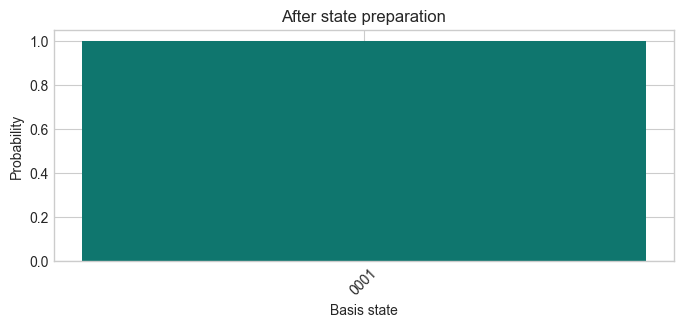

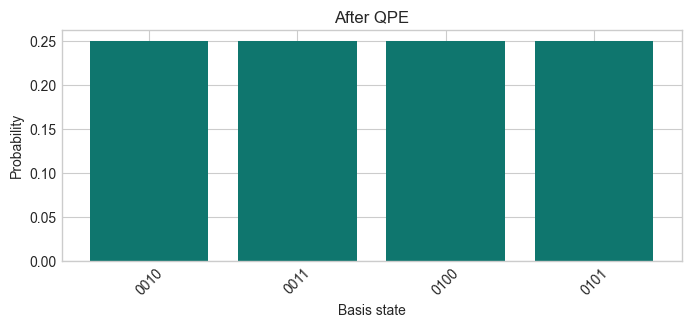

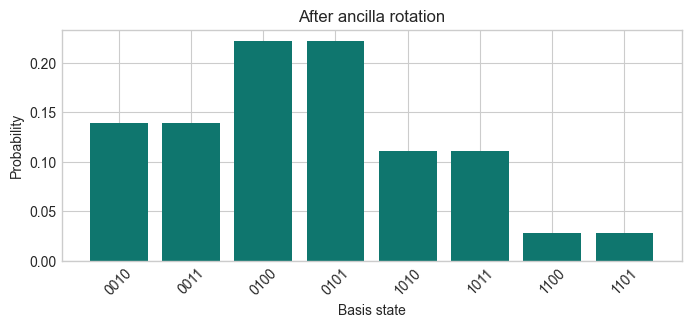

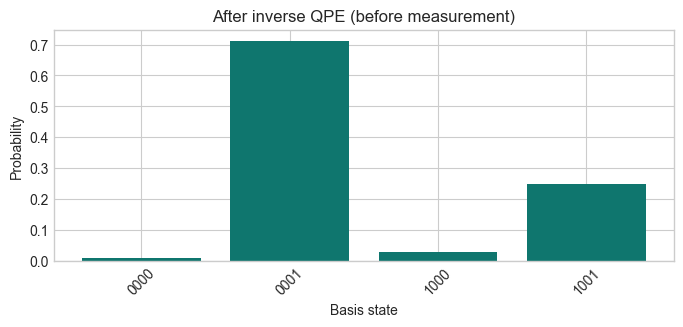

Final statevector probabilities:
{np.str_('0000'): np.float64(0.009747), np.str_('0001'): np.float64(0.712475), np.str_('1000'): np.float64(0.027778), np.str_('1001'): np.float64(0.25)}


In [7]:
circuit0, circuit1, circuit2, circuit3, sv_prepare, sv_qpe, sv_rotation, sv_final = run_hhl_demo(example, U, U2)

display_circuit(circuit0)
display_circuit(circuit1)
display_circuit(circuit2)
display_circuit(circuit3)

plot_probabilities(sv_prepare, "After state preparation")
plot_probabilities(sv_qpe, "After QPE")
plot_probabilities(sv_rotation, "After ancilla rotation")
plot_probabilities(sv_final, "After inverse QPE (before measurement)")

print("Final statevector probabilities:")
print(format_probability_dict(sv_final.probabilities_dict()))

In [ ]:
# Compute the classical solution for reference
classical_solution = np.linalg.solve(example.matrix, example.b)
classical_normalized = normalize_state(classical_solution)

print("=" * 60)
print("CLASSICAL SOLUTION")
print("=" * 60)
print(f"A @ x = b  =>  x = A^(-1) @ b")
print(f"x (unnormalized) = {classical_solution}")
print(f"x (normalized)   = {classical_normalized}")
print()

# Extract the quantum solution from the final statevector
print("=" * 60)
print("QUANTUM SOLUTION INTERPRETATION")
print("=" * 60)
probs = sv_final.probabilities_dict()

(
    ancilla_0_probs,
    ancilla_1_probs,
    total_ancilla_0,
    total_ancilla_1,
    normalized_solution,
) = extract_postselected_solution(probs)

print(f"Ancilla = 0 (failure): {total_ancilla_0:.6f}")
print(f"  System states: {ancilla_0_probs}")
print()
print(f"Ancilla = 1 (success): {total_ancilla_1:.6f}")
print(f"  System states: {ancilla_1_probs}")
print()

# Post-select on ancilla = 1
if normalized_solution:
    print("POST-SELECTED SOLUTION (ancilla = 1):")
    for state, prob in sorted(normalized_solution.items()):
        print(f"  |{state}⟩: {prob:.6f}")
    print()
    
    # Map to amplitudes
    solution_amplitude_0 = np.sqrt(normalized_solution.get('0', 0.0))
    solution_amplitude_1 = np.sqrt(normalized_solution.get('1', 0.0))
    quantum_solution = np.array([solution_amplitude_0, solution_amplitude_1], dtype=complex)
    
    print("Quantum solution state: ", quantum_solution)
    print("Classical solution:    ", classical_normalized)
    print()
    
    # Compute fidelity
    fidelity = abs(np.vdot(quantum_solution, classical_normalized)) ** 2
    print(f"Fidelity (overlap squared): {fidelity:.6f}")
else:
    print("Warning: No successful postselection (ancilla = 1)")

CLASSICAL SOLUTION
A @ x = b  =>  x = A^(-1) @ b
x (unnormalized) = [0.375+0.j 1.125+0.j]
x (normalized)   = [0.3162+0.j 0.9487+0.j]

QUANTUM SOLUTION INTERPRETATION
Ancilla = 0 (failure): 0.722222
  System states: {'0': np.float64(0.009746926647957904), '1': np.float64(0.7124752955742626)}

Ancilla = 1 (success): 0.277778
  System states: {'0': np.float64(0.027777777777777655), '1': np.float64(0.24999999999999944)}

POST-SELECTED SOLUTION (ancilla = 1):
  |0⟩: 0.100000
  |1⟩: 0.900000

Quantum solution state:  [0.3162+0.j 0.9487+0.j]
Classical solution:     [0.3162+0.j 0.9487+0.j]

Fidelity (overlap squared): 1.000000


## 4. Understanding the HHL Algorithm Flow

The HHL algorithm solves $A\,x = b$ by:

1. **Prepare $|b\rangle$** on the system qubit.

2. **Quantum Phase Estimation (QPE)** estimates the eigenvalues of $A$:
   - Each eigenvalue $\lambda$ gets encoded as a phase on the clock qubits.
   - In our teaching example: $\lambda_0 \to |10\rangle$, $\lambda_1 \to |01\rangle$.

3. **Controlled Rotation** on the ancilla encodes the reciprocal:
   - For each eigenvalue $\lambda$, apply $R_y(2\arcsin(c/\lambda))$ **if the ancilla is 1**.
   - Small $\lambda$ → large rotation → ancilla mostly in $|1\rangle$.
   - Large $\lambda$ → small rotation → ancilla mostly in $|0\rangle$.
   - **The ancilla acts as a "success flag"**: post-select on ancilla $= 1$ to keep only good solutions.

4. **Inverse QPE** uncomputes the clock qubits, leaving the solution in the system qubit.

5. **Measurement** collapses to a classical outcome. Post-selecting on ancilla $= 1$ gives the solution.

**Key insight:** The success probability (ancilla $= 1$) depends on the condition number of $A$ and the scaling parameter $c$. Real QPE circuits have noise; the probabilities reflect how well the algorithm separates eigenvalues and encodes them.